# Проверка гипотез сервиса аренды самокатов

**Цель проекта:** проверка гипотез для успешного проведения акций сервиса аренды самокатов GoFast
1. Тратят ли пользователи с подпиской больше времени на поездки?
2. Можно ли сказать, что расстояние, которое проезжают пользователи с подпиской за одну поездку, не превышает 3130 метров?
3. Будет ли помесячная выручка от пользователей с подпиской по месяцам выше, чем выручка от пользователей без подписки?

**Ход выполнения проекта:**
Данные будут взяты из 3 файлов: users_go.csv, rides_go.csv, subscriptions_go.csv. Качество данных неизвестно, поэтому перед стартом использования данных для проверки гипотез будет выполнен обзор полученных данных, при необходимсти их предобработка и анализ.

План выполнения проекта:
1. Обзор данных
2. Предобработка данных
3. Исследование общей информации о пользователях и поездках
4. Объединение данных в одну сводную таблицу для удобства проверки гипотез
5. Проведение дополнительных расчётов суммарных значений по имеющимся данным
6. Проверка гипотез

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as st

## Загрузка данных

In [2]:
try:
    rides = pd.read_csv('/datasets/rides_go.csv')
except:
    rides = pd.read_csv('https://code.s3.yandex.net/datasets/rides_go.csv')
    
rides.head()

,user_id,distance,duration,date
0,1,4409.919140,25.599769,2021-01-01
1,1,2617.592153,15.816871,2021-01-18
2,1,754.159807,6.232113,2021-04-20
3,1,2694.783254,18.511000,2021-08-11
4,1,4028.687306,26.265803,2021-08-28


In [3]:
rides.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18068 entries, 0 to 18067
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   user_id   18068 non-null  int64  
 1   distance  18068 non-null  float64
 2   duration  18068 non-null  float64
 3   date      18068 non-null  object 
dtypes: float64(2), int64(1), object(1)
memory usage: 564.8+ KB


In [4]:
try:
    subscriptions = pd.read_csv('/datasets/subscriptions_go.csv')
except:
    subscriptions = pd.read_csv('https://code.s3.yandex.net/datasets/subscriptions_go.csv')
    
subscriptions.head()

,subscription_type,minute_price,start_ride_price,subscription_fee
0,free,8,50,0
1,ultra,6,0,199


In [5]:
subscriptions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   subscription_type  2 non-null      object
 1   minute_price       2 non-null      int64 
 2   start_ride_price   2 non-null      int64 
 3   subscription_fee   2 non-null      int64 
dtypes: int64(3), object(1)
memory usage: 192.0+ bytes


In [6]:
try:
    users = pd.read_csv('/datasets/users_go.csv')
except:
    users = pd.read_csv('https://code.s3.yandex.net/datasets/users_go.csv')
    
users.head()

,user_id,name,age,city,subscription_type
0,1,Кира,22,Тюмень,ultra
1,2,Станислав,31,Омск,ultra
2,3,Алексей,20,Москва,ultra
3,4,Константин,26,Ростов-на-Дону,ultra
4,5,Адель,28,Омск,ultra


In [7]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1565 entries, 0 to 1564
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user_id            1565 non-null   int64 
 1   name               1565 non-null   object
 2   age                1565 non-null   int64 
 3   city               1565 non-null   object
 4   subscription_type  1565 non-null   object
dtypes: int64(2), object(3)
memory usage: 61.3+ KB


*В rides хранится информация о 18068 поездках, пропущенных значений в столбцах таблицы нет*<br>
*Данные в subscriptions соответствуют полученной информации о подписке*<br>
*В users хранится информация о 1565 пользователях, пропущенных значений в столбцах таблицы нет*

## Предобработка данных

### Приведение столбца date к типу даты pandas

In [8]:
rides['date'] = pd.to_datetime(rides['date'], format='%Y-%m-%d')
print(type(rides['date'][0]))
rides.head()

<class 'pandas._libs.tslibs.timestamps.Timestamp'>


,user_id,distance,duration,date
0,1,4409.919140,25.599769,2021-01-01
1,1,2617.592153,15.816871,2021-01-18
2,1,754.159807,6.232113,2021-04-20
3,1,2694.783254,18.511000,2021-08-11
4,1,4028.687306,26.265803,2021-08-28


### Создание нового столбца с номером месяца на основе столбца date

In [9]:
rides['month'] = pd.DatetimeIndex(rides['date']).month
rides.head()

,user_id,distance,duration,date,month
0,1,4409.919140,25.599769,2021-01-01,1
1,1,2617.592153,15.816871,2021-01-18,1
2,1,754.159807,6.232113,2021-04-20,4
3,1,2694.783254,18.511000,2021-08-11,8
4,1,4028.687306,26.265803,2021-08-28,8


### Проверка и обработка пропущенных значений и дубликатов

In [10]:
rides.duplicated().sum()

0

In [11]:
users.duplicated().sum()

31

In [12]:
users = users.drop_duplicates()
users.duplicated().sum()

0

In [13]:
users['user_id'].duplicated().sum()

0

*Из users был удален 31 дубликат. Другие 2 таблицы дубликатов не имели.*<br>
*По выводу info на шаге 1 видно, что во всех 3 таблицах отсутсвуют пропуски значений.*

## Исследовательский анализ данных

### Частота встречаемости городов

In [14]:
users['city'].value_counts()

Пятигорск         219
Екатеринбург      204
Ростов-на-Дону    198
Краснодар         193
Сочи              189
Омск              183
Тюмень            180
Москва            168
Name: city, dtype: int64

In [15]:
count_by_city = users['city'].value_counts()

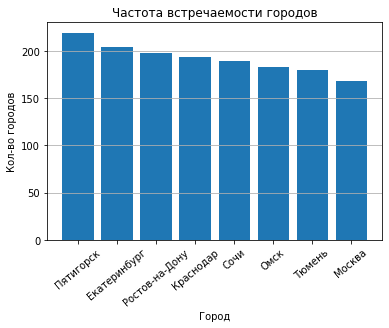

In [16]:
#plt.figure(figsize = (6, 4))

plt.bar(count_by_city.index, count_by_city.values)

plt.xlabel('Город')
plt.ylabel('Кол-во городов')
plt.title('Частота встречаемости городов')
plt.grid(axis='y')
plt.xticks(rotation = 40)
plt.show()

*Наибольшее количество пользователей в Пятигорске, наименьшее в Москве. На графике представлены города, по выборкам которых будет выполняться проверка гипотез.*

### Соотношение пользователей с подпиской и без подписки

In [17]:
users['subscription_type'].value_counts()

free     835
ultra    699
Name: subscription_type, dtype: int64

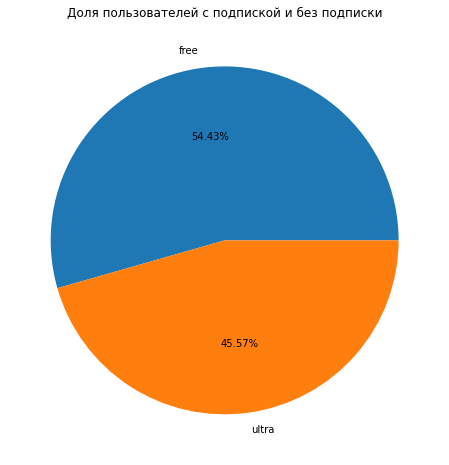

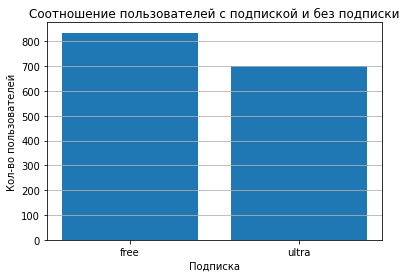

In [18]:
count_by_subscription = users['subscription_type'].value_counts()

plt.figure(figsize = (12, 8))

plt.pie(count_by_subscription, labels=count_by_subscription.index, autopct='%1.2f%%')
plt.title('Доля пользователей с подпиской и без подписки')
plt.show()

plt.bar(count_by_subscription.index, count_by_subscription.values)
plt.xlabel('Подписка')
plt.ylabel('Кол-во пользователей')
plt.title('Соотношение пользователей с подпиской и без подписки')
plt.grid(axis='y')
plt.show()

*Доля пользователей с подпиской чуть больше, чем пользователей без подписки - 54,43% против 45,57%. При сравнении данных для проверки гипотез это будет являться плюсом, т.к. не будет сильного перекоса в сторону одного из сетов.*

### Возраст пользователей

In [19]:
users['age'].describe()

count    1534.000000
mean       24.903520
std         4.572367
min        12.000000
25%        22.000000
50%        25.000000
75%        28.000000
max        43.000000
Name: age, dtype: float64

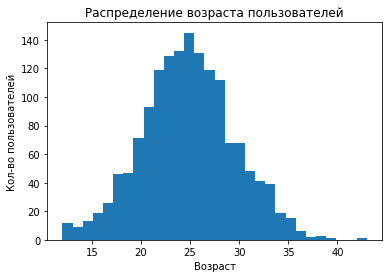

In [20]:
plt.hist(users['age'], bins=30)
plt.xlabel('Возраст')
plt.ylabel('Кол-во пользователей')
plt.title('Распределение возраста пользователей')
plt.show()

*Возраст пользователей от 12 до 43 лет. График имеет нормальное распределение. Средний возраст около 25 лет, что вполне похоже на правду.*

### Расстояние, которое пользователь преодолел за одну поездку

In [21]:
rides['distance'].describe()

count    18068.000000
mean      3070.659976
std       1116.831209
min          0.855683
25%       2543.226360
50%       3133.609994
75%       3776.222735
max       7211.007745
Name: distance, dtype: float64

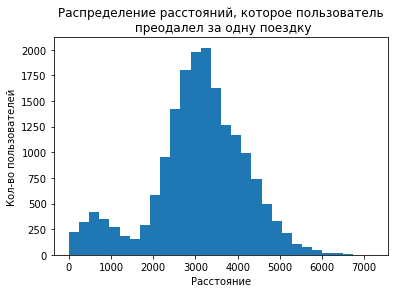

In [22]:
plt.hist(rides['distance'], bins=30)
plt.xlabel('Расстояние')
plt.ylabel('Кол-во пользователей')
plt.title('Распределение расстояний, которое пользователь\n преодалел за одну поездку')
plt.show()

*График имеет 2 пика. Среди коротких расстояний есть пиковое значение около 600 метров, среди длинных - около 3300. Сами данные выглядят корректно. Заряда аккумулятора среднестатистического самоката хватает на 20-30 км, в данных за одну поездку проезжали менее 7 км.*

### Продолжительность поездок

In [23]:
rides['duration'].describe()

count    18068.000000
mean        17.805011
std          6.091051
min          0.500000
25%         13.597563
50%         17.678395
75%         21.724800
max         40.823963
Name: duration, dtype: float64

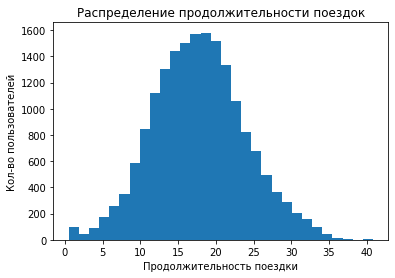

In [24]:
plt.hist(rides['duration'], bins=30)
plt.xlabel('Продолжительность поездки')
plt.ylabel('Кол-во пользователей')
plt.title('Распределение продолжительности поездок')
plt.show()

*График имеет нормальное распределение. Среднее и медианное значения почти совпадают, 17.8 минут. Есть небольшой пик на очень малых значениях - поездки меньше минуты, возможно из-за быстрого отказа от поездки (пользователь передумал ехать или что-то не получилось) или из-за нехватки заряда.*

*Данные в предоставленной выборке выглядят корректно. С ними можно работать для проверки гипотез.*

## Объединение данных

### Объединение данных о пользователях, поездках и подписках в один датафрейм

In [25]:
common_df = rides.merge(users, on='user_id')
common_df.head()

,user_id,distance,duration,date,month,name,age,city,subscription_type
0,1,4409.919140,25.599769,2021-01-01,1,Кира,22,Тюмень,ultra
1,1,2617.592153,15.816871,2021-01-18,1,Кира,22,Тюмень,ultra
2,1,754.159807,6.232113,2021-04-20,4,Кира,22,Тюмень,ultra
3,1,2694.783254,18.511000,2021-08-11,8,Кира,22,Тюмень,ultra
4,1,4028.687306,26.265803,2021-08-28,8,Кира,22,Тюмень,ultra


In [26]:
common_df = common_df.merge(subscriptions, on='subscription_type')
common_df.head()

,user_id,distance,duration,date,month,name,age,city,subscription_type,minute_price,start_ride_price,subscription_fee
0,1,4409.919140,25.599769,2021-01-01,1,Кира,22,Тюмень,ultra,6,0,199
1,1,2617.592153,15.816871,2021-01-18,1,Кира,22,Тюмень,ultra,6,0,199
2,1,754.159807,6.232113,2021-04-20,4,Кира,22,Тюмень,ultra,6,0,199
3,1,2694.783254,18.511000,2021-08-11,8,Кира,22,Тюмень,ultra,6,0,199
4,1,4028.687306,26.265803,2021-08-28,8,Кира,22,Тюмень,ultra,6,0,199


In [27]:
common_df['duration_rounded'] = np.ceil(common_df['duration'])

In [28]:
common_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 18068 entries, 0 to 18067
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            18068 non-null  int64         
 1   distance           18068 non-null  float64       
 2   duration           18068 non-null  float64       
 3   date               18068 non-null  datetime64[ns]
 4   month              18068 non-null  int64         
 5   name               18068 non-null  object        
 6   age                18068 non-null  int64         
 7   city               18068 non-null  object        
 8   subscription_type  18068 non-null  object        
 9   minute_price       18068 non-null  int64         
 10  start_ride_price   18068 non-null  int64         
 11  subscription_fee   18068 non-null  int64         
 12  duration_rounded   18068 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(6), object(3)
memory 

*Создана общая таблица, хранящая данные из 3 исходных таблиц. Количество строк осталось верным - 18 068 (соответствует количеству поездок в rides_go.csv)*

### Создание датафрейма c данными о пользователях без подписки

In [29]:
rides_without_subscribes = common_df[common_df['subscription_type'] == 'free']
rides_without_subscribes.head()

,user_id,distance,duration,date,month,name,age,city,subscription_type,minute_price,start_ride_price,subscription_fee,duration_rounded
6500,700,2515.690719,14.944286,2021-01-02,1,Айдар,22,Омск,free,8,50,0,15.0
6501,700,846.932642,16.234663,2021-02-01,2,Айдар,22,Омск,free,8,50,0,17.0
6502,700,4004.434142,20.016628,2021-02-04,2,Айдар,22,Омск,free,8,50,0,21.0
6503,700,1205.911290,9.782872,2021-02-10,2,Айдар,22,Омск,free,8,50,0,10.0
6504,700,3047.379435,17.427673,2021-02-14,2,Айдар,22,Омск,free,8,50,0,18.0


In [30]:
rides_without_subscribes.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 11568 entries, 6500 to 18067
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            11568 non-null  int64         
 1   distance           11568 non-null  float64       
 2   duration           11568 non-null  float64       
 3   date               11568 non-null  datetime64[ns]
 4   month              11568 non-null  int64         
 5   name               11568 non-null  object        
 6   age                11568 non-null  int64         
 7   city               11568 non-null  object        
 8   subscription_type  11568 non-null  object        
 9   minute_price       11568 non-null  int64         
 10  start_ride_price   11568 non-null  int64         
 11  subscription_fee   11568 non-null  int64         
 12  duration_rounded   11568 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(6), object(3)
memo

### Создание датафрейма c данными о пользователях с подпиской

In [31]:
rides_with_subscribes = common_df[common_df['subscription_type'] == 'ultra']
rides_with_subscribes.head()

,user_id,distance,duration,date,month,name,age,city,subscription_type,minute_price,start_ride_price,subscription_fee,duration_rounded
0,1,4409.919140,25.599769,2021-01-01,1,Кира,22,Тюмень,ultra,6,0,199,26.0
1,1,2617.592153,15.816871,2021-01-18,1,Кира,22,Тюмень,ultra,6,0,199,16.0
2,1,754.159807,6.232113,2021-04-20,4,Кира,22,Тюмень,ultra,6,0,199,7.0
3,1,2694.783254,18.511000,2021-08-11,8,Кира,22,Тюмень,ultra,6,0,199,19.0
4,1,4028.687306,26.265803,2021-08-28,8,Кира,22,Тюмень,ultra,6,0,199,27.0


In [32]:
rides_with_subscribes.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 6500 entries, 0 to 6499
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            6500 non-null   int64         
 1   distance           6500 non-null   float64       
 2   duration           6500 non-null   float64       
 3   date               6500 non-null   datetime64[ns]
 4   month              6500 non-null   int64         
 5   name               6500 non-null   object        
 6   age                6500 non-null   int64         
 7   city               6500 non-null   object        
 8   subscription_type  6500 non-null   object        
 9   minute_price       6500 non-null   int64         
 10  start_ride_price   6500 non-null   int64         
 11  subscription_fee   6500 non-null   int64         
 12  duration_rounded   6500 non-null   float64       
dtypes: datetime64[ns](1), float64(3), int64(6), object(3)
memory us

*Созданы 2 таблицы: с данными пользователей с подпиской и с данными пользователей без подписки. Количество записей соответствует общему количеству поездок.*

### Информация о расстоянии и времени поездок для пользователей с разделением на категории

###### Пользователи без подписки

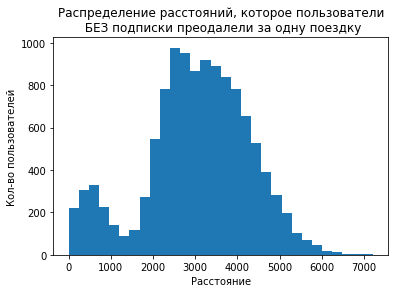

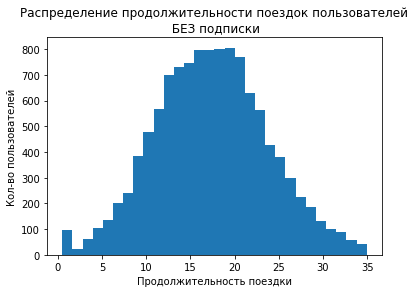

In [33]:
plt.hist(rides_without_subscribes['distance'], bins=30)
plt.xlabel('Расстояние')
plt.ylabel('Кол-во пользователей')
plt.title('Распределение расстояний, которое пользователи\n БЕЗ подписки преодалели за одну поездку')
plt.show()

plt.hist(rides_without_subscribes['duration'], bins=30)
plt.xlabel('Продолжительность поездки')
plt.ylabel('Кол-во пользователей')
plt.title('Распределение продолжительности поездок пользователей\n БЕЗ подписки')
plt.show()

###### Пользователи с подпиской

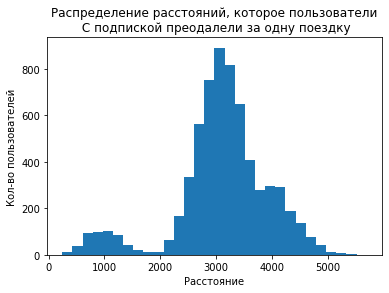

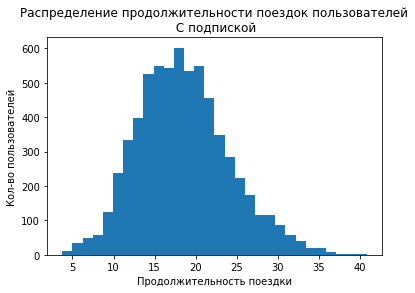

In [34]:
plt.hist(rides_with_subscribes['distance'], bins=30)
plt.xlabel('Расстояние')
plt.ylabel('Кол-во пользователей')
plt.title('Распределение расстояний, которое пользователи\n С подпиской преодалели за одну поездку')
plt.show()

plt.hist(rides_with_subscribes['duration'], bins=30)
plt.xlabel('Продолжительность поездки')
plt.ylabel('Кол-во пользователей')
plt.title('Распределение продолжительности поездок пользователей\n С подпиской')
plt.show()

###### Сравнение расстояний

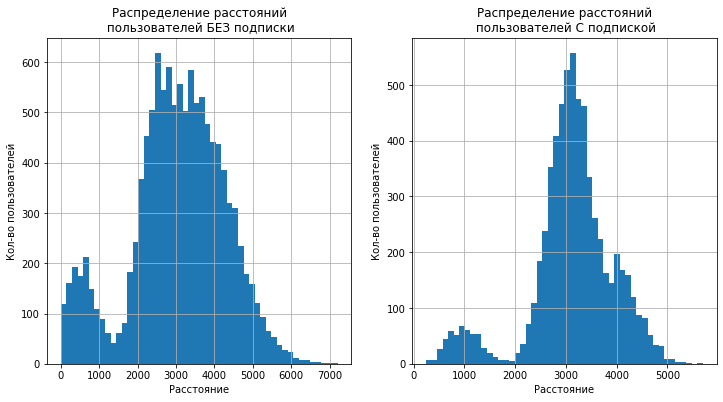

In [35]:
figure, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,6))

ax[0].hist(rides_without_subscribes['distance'], bins=50)
ax[0].set_xlabel('Расстояние')
ax[0].set_ylabel('Кол-во пользователей')
ax[0].set_title('Распределение расстояний\n пользователей БЕЗ подписки')
ax[0].grid()

ax[1].hist(rides_with_subscribes['distance'], bins=50)
ax[1].set_xlabel('Расстояние')
ax[1].set_ylabel('Кол-во пользователей')
ax[1].set_title('Распределение расстояний\n пользователей С подпиской')
ax[1].grid()

plt.show()

*Графики распределения расстояний примерно одинаковые у пользователей с подпиской и без. У пользователей без подписки наблюдается самый большой пик около 2600, у пользователей с подпиской - около 3100.*

###### Сравнение времени поездок

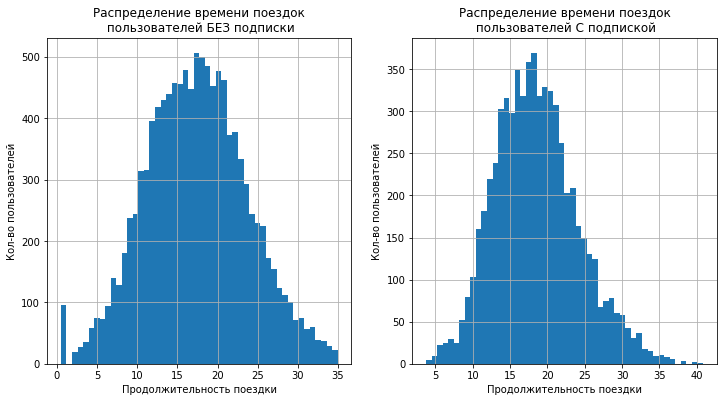

In [36]:
figure, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,6))

ax[0].hist(rides_without_subscribes['duration'], bins=50)
ax[0].set_xlabel('Продолжительность поездки')
ax[0].set_ylabel('Кол-во пользователей')
ax[0].set_title('Распределение времени поездок\n пользователей БЕЗ подписки')
ax[0].grid()

ax[1].hist(rides_with_subscribes['duration'], bins=50)
ax[1].set_xlabel('Продолжительность поездки')
ax[1].set_ylabel('Кол-во пользователей')
ax[1].set_title('Распределение времени поездок\n пользователей С подпиской')
ax[1].grid()

plt.show()

*Распределение времени поездок у пользователей с подпиской и без примерно одинаковое. Единственное, у пользователей без подписки есть скачок в очень коротких поездках (до минуты).*

*Распределения по расстоянию и по времени поездок для обоих сетов примерно одинаковое, значит данные хорошо подходят для дальнейшей проверки гипотез.*

## Подсчёт выручки

### Агрегированные данные о поездках 

суммарное расстояние, количество поездок и суммарное время для каждого пользователя за каждый месяц

In [37]:
#rides_with_subscribes['duration_rounded'] = np.ceil(rides_with_subscribes['duration'])
rides_with_subscribes.head()

,user_id,distance,duration,date,month,name,age,city,subscription_type,minute_price,start_ride_price,subscription_fee,duration_rounded
0,1,4409.919140,25.599769,2021-01-01,1,Кира,22,Тюмень,ultra,6,0,199,26.0
1,1,2617.592153,15.816871,2021-01-18,1,Кира,22,Тюмень,ultra,6,0,199,16.0
2,1,754.159807,6.232113,2021-04-20,4,Кира,22,Тюмень,ultra,6,0,199,7.0
3,1,2694.783254,18.511000,2021-08-11,8,Кира,22,Тюмень,ultra,6,0,199,19.0
4,1,4028.687306,26.265803,2021-08-28,8,Кира,22,Тюмень,ultra,6,0,199,27.0


In [38]:
agg_with_subscribes = rides_with_subscribes.groupby(['user_id','month']).agg(
    distance_sum = ('distance','sum'), 
    rides_count = ('name','count'), 
    duration_sum = ('duration_rounded','sum')
).reset_index()
agg_with_subscribes.head()

,user_id,month,distance_sum,rides_count,duration_sum
0,1,1,7027.511294,2,42.0
1,1,4,754.159807,1,7.0
2,1,8,6723.470560,2,46.0
3,1,10,5809.911100,2,32.0
4,1,11,7003.499363,3,56.0


In [39]:
#rides_without_subscribes['duration_rounded'] = np.ceil(rides_without_subscribes['duration'])
rides_without_subscribes.head()

,user_id,distance,duration,date,month,name,age,city,subscription_type,minute_price,start_ride_price,subscription_fee,duration_rounded
6500,700,2515.690719,14.944286,2021-01-02,1,Айдар,22,Омск,free,8,50,0,15.0
6501,700,846.932642,16.234663,2021-02-01,2,Айдар,22,Омск,free,8,50,0,17.0
6502,700,4004.434142,20.016628,2021-02-04,2,Айдар,22,Омск,free,8,50,0,21.0
6503,700,1205.911290,9.782872,2021-02-10,2,Айдар,22,Омск,free,8,50,0,10.0
6504,700,3047.379435,17.427673,2021-02-14,2,Айдар,22,Омск,free,8,50,0,18.0


In [40]:
agg_without_subscribes = rides_without_subscribes.groupby(['user_id','month']).agg(
    distance_sum = ('distance','sum'), 
    rides_count = ('name','count'), 
    duration_sum = ('duration_rounded','sum')
).reset_index()
agg_without_subscribes.head()

,user_id,month,distance_sum,rides_count,duration_sum
0,700,1,2515.690719,1,15.0
1,700,2,13446.659764,5,89.0
2,700,3,3798.334905,1,19.0
3,700,4,2984.551206,1,16.0
4,700,6,5927.650988,2,29.0


### Расчёт помесячной выручки, которую принёс каждый пользователь

###### Расчёт выручки пользователей с подпиской

In [41]:
#agg_with_subscribes['duration_rounded'] = np.ceil(agg_with_subscribes['duration_sum'])
#agg_with_subscribes.head()

In [42]:
agg_with_subscribes['revenue'] = 6 * agg_with_subscribes['duration_sum'] + 199
agg_with_subscribes.head(10)

,user_id,month,distance_sum,rides_count,duration_sum,revenue
0,1,1,7027.511294,2,42.0,451.0
1,1,4,754.159807,1,7.0,241.0
2,1,8,6723.470560,2,46.0,475.0
3,1,10,5809.911100,2,32.0,391.0
4,1,11,7003.499363,3,56.0,535.0
5,1,12,6751.629942,2,28.0,367.0
6,2,3,10187.723006,3,63.0,577.0
7,2,4,6164.381824,2,40.0,439.0
8,2,6,3255.338202,1,14.0,283.0
9,2,7,6780.722964,2,48.0,487.0


###### Расчёт выручки пользователей без подписки

In [43]:
#agg_without_subscribes['duration_rounded'] = np.ceil(agg_without_subscribes['duration_sum'])
#agg_without_subscribes.head()

In [44]:
agg_without_subscribes['revenue'] = (50 * agg_without_subscribes['rides_count']) + (8 * agg_without_subscribes['duration_sum'])
agg_without_subscribes.head(10)

,user_id,month,distance_sum,rides_count,duration_sum,revenue
0,700,1,2515.690719,1,15.0,170.0
1,700,2,13446.659764,5,89.0,962.0
2,700,3,3798.334905,1,19.0,202.0
3,700,4,2984.551206,1,16.0,178.0
4,700,6,5927.650988,2,29.0,332.0
5,700,7,4399.206279,2,21.0,268.0
6,700,8,4071.654669,1,17.0,186.0
7,700,10,6322.578618,2,44.0,452.0
8,700,11,8735.782625,3,32.0,406.0
9,701,1,2676.472894,1,18.0,194.0


## Проверка гипотез

### Тратят ли пользователи с подпиской больше времени на поездки?

Важно понять, тратят ли пользователи с подпиской больше времени на поездки? Если да, то пользователи с подпиской могут быть «выгоднее» для компании. Проверьте гипотезу. Используйте исходные данные о продолжительности каждой сессии — отдельно для подписчиков и тех, у кого нет подписки.

Гипотеза 0 - среднее время на поездки, потраченное пользователями с подпиской и без, равно<br>
Гипотеза 1 - среднее время на поездки у пользователей с подпиской больше, чем у пользователей без подписки

In [45]:
# уровень статистической значимости
alpha = 0.05

# выполнение ttest для двух выборок, в качестве альтернативной используется односторонняя гипотеза "больше"
results = st.ttest_ind(rides_with_subscribes['duration'], rides_without_subscribes['duration'], alternative='greater')

print(f'p-value: {results.pvalue}')

# проверка p-value
if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Нет оснований отвергнуть нулевую гипотезу')

p-value: 1.2804098316645618e-34
Отвергаем нулевую гипотезу


*Вероятность получить продолжительность поездок пользователей с подпиской равную продолжительности поездок пользователей без подписки очень мала. Поэтому нулевая гипотеза была отвергнута в пользу первой - "среднее время на поездки у пользователей с подпиской больше, чем у пользователей без подписки". Значит пользователи с подпиской выгоднее для компании.*

### Можно ли сказать, что расстояние, которое проезжают пользователи с подпиской за одну поездку, не превышает 3130 метров?

Расстояние одной поездки в 3130 метров — оптимальное с точки зрения износа самоката. Можно ли сказать, что расстояние, которое проезжают пользователи с подпиской за одну поездку, не превышает 3130 метров?

Гипотеза 0 - среднее расстояние, которое проезжают пользователи с подпиской за одну поездку, равно 3130 метров <br>
Гипотеза 1 - среднее расстояние, которое проезжают пользователи с подпиской за одну поездку, больше 3130 метров

In [46]:
# оптимальное значение с точки зрения износа самоката
optimal_value = 3130

# уровень статистической значимости
alpha = 0.05

# проверка односторонней гипотезы о равенстве среднего генеральной совокупности определённому значению
results = st.ttest_1samp(
    rides_with_subscribes['distance'], 
    optimal_value,
    alternative='greater')

print('p-значение:', results.pvalue)

# проверка p-value
if (results.pvalue < alpha):
    print('Отвергаем нулевую гипотезу')
else:
    print('Не отвергаем нулевую гипотезу')

p-значение: 0.9195368847849785
Не отвергаем нулевую гипотезу


*Гипотеза "среднее расстояние, которое проезжают пользователи с подпиской за одну поездку, равно 3130 метров" не была отвергнута. Значит нельзя сказать, что расстояние, которое проезжают пользователи с подпиской за одну поездку, не превышает 3130 метров*

### Будет ли помесячная выручка от пользователей с подпиской по месяцам выше, чем выручка от пользователей без подписки?

Проверьте гипотезу о том, будет ли помесячная выручка от пользователей с подпиской по месяцам выше, чем выручка от пользователей без подписки.

Гипотеза 0 - средние помесячные выручки пользователей с подпиской и без подписки равны<br>
Гипотеза 1 - средняя помесячная выручка пользователей с подпиской выше, чем средняя выручка от пользователей без подписки

In [47]:
# уровень статистической значимости
alpha = 0.05

# выполнение ttest для двух выборок, в качестве альтернативной используется односторонняя гипотеза "больше"
results = st.ttest_ind(agg_with_subscribes['revenue'], agg_without_subscribes['revenue'], alternative='greater')

print(f'p-value: {results.pvalue}')

# проверка p-value
if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Нет оснований отвергнуть нулевую гипотезу')

p-value: 1.8850394384715216e-31
Отвергаем нулевую гипотезу


*Вероятность получить выручку от пользователей с подпиской равную выручке от пользователей без подписки очень мала. Поэтому нулевая гипотеза была отвергнута в пользу первой - "средняя помесячная выручка пользователей с подпиской выше, чем средняя выручка от пользователей без подписки". Значит предположение подтвердилось.*

### Теоритическая гипотеза

**Вопрос.** Представьте такую ситуацию: техническая команда сервиса обновила сервера, с которыми взаимодействует мобильное приложение. Она надеется, что из-за этого количество обращений в техподдержку значимо снизилось. Некоторый файл содержит для каждого пользователя данные о количестве обращений до обновления и после него. Какой тест вам понадобился бы для проверки этой гипотезы?

**Ответ.** Для проверки данной гипотезы необходимо воспользоваться методом scipy.stats.ttest_rel(), т.к. необходимо проверить гипотезу о равенстве средних для зависимых (парных) выборок.

# Вывод

В ходе работы над проектом было выполнено:
1. Обработка и исследование полученных данных
2. Анализ данных
3. Объединение данных из 3 файлов и разбиение данных на 2 категории - данные пользователей с подпиской и данные пользователей без полписки
4. Расчёт помесячной выручки, которую приносят пользователи
5. Проверка гипотез

**При проверке гипотез были сделаны выводы** (результаты можно увидеть в разделе 6):
1. Тратят ли пользователи с подпиской больше времени на поездки?
> Да. Пользователи с подпиской выгоднее для компании, т.к. тратят больше времени на поездки.
2. Можно ли сказать, что расстояние, которое проезжают пользователи с подпиской за одну поездку, не превышает 3130 метров?
> Нет. Среднее расстояние, которое проезжают пользователи с подпиской за одну поездку равно 3130 метрам
3. Будет ли помесячная выручка от пользователей с подпиской по месяцам выше, чем выручка от пользователей без подписки?
> Да. Средняя помесячная выручка пользователей с подпиской выше, чем средняя выручка от пользователей без подписки